# Membrane Channel — Registration Error Over Time

Z-plane projection pipeline (smoothPenalty=0.03, ref update every 40 frames).
Metrics computed as **mov vs mem_mapped** (warped reference reconstruction).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_DIR = Path("/home/cyf/wbi/Virginia/registrated_data/f260517/f260517_0625/diagnostics")

df_mem = pd.read_csv(CSV_DIR / "errors_membrane.csv")

frames = df_mem["frame"].values
print(f"Loaded: {df_mem.shape[0]} rows")
print(f"Columns: {list(df_mem.columns)}")
print(f"\nQuick stats:")
print(df_mem[["MAE", "nMAE", "NCC", "edge"]].describe().round(4).to_string())

Loaded: 200 rows
Columns: ['frame', 'ref_update_id', 'MAE', 'nMAE', 'NCC', 'edge', 'hole_frac', 'elapsed_s']

Quick stats:
            MAE      nMAE       NCC      edge
count  200.0000  200.0000  200.0000  200.0000
mean    54.5056    0.0133    0.7372    0.5282
std     12.7587    0.0031    0.0422    0.0371
min     18.9529    0.0049    0.5878    0.4671
25%     45.9429    0.0115    0.7149    0.4936
50%     55.1298    0.0133    0.7388    0.5277
75%     62.9505    0.0155    0.7624    0.5654
max     85.8585    0.0218    0.8224    0.6015


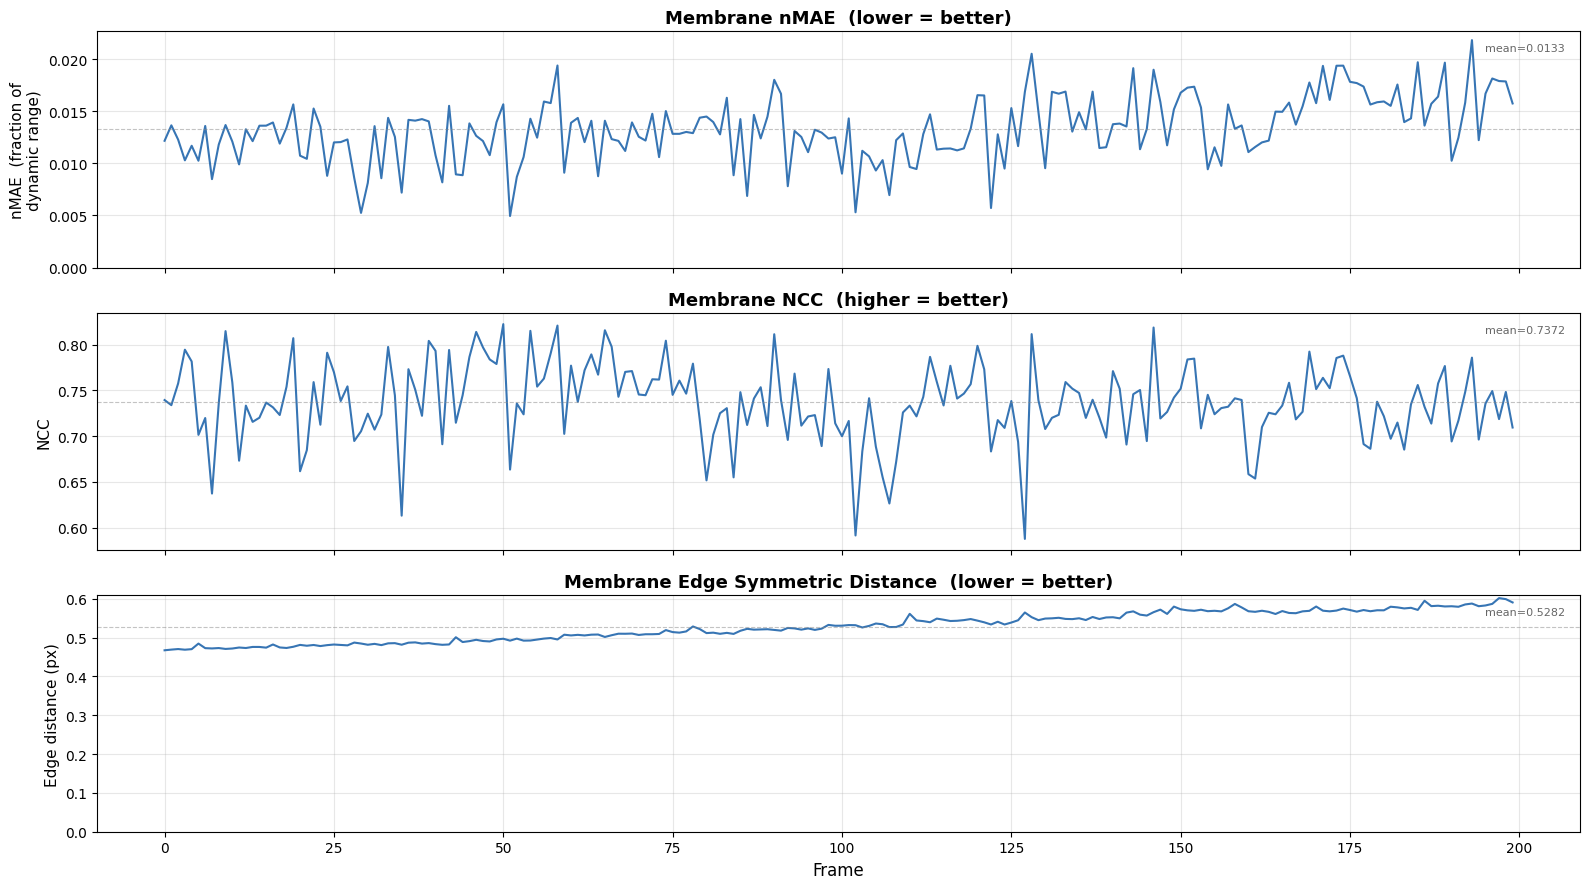

Saved to membrane_metrics_timeseries.png


In [6]:
# ================================================================
# Figure: 3-panel membrane metrics over time
# ================================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

color_reg = "#2166AC"

# --- Panel 1: nMAE ---
ax = axes[0]
ax.plot(frames, df_mem["nMAE"], color=color_reg, lw=1.5, alpha=0.9)
ax.set_ylabel("nMAE  (fraction of\ndynamic range)", fontsize=11)
ax.set_title("Membrane nMAE  (lower = better)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

# --- Panel 2: NCC ---
ax = axes[1]
ax.plot(frames, df_mem["NCC"], color=color_reg, lw=1.5, alpha=0.9)
ax.set_ylabel("NCC", fontsize=11)
ax.set_title("Membrane NCC  (higher = better)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)

# --- Panel 3: Edge symmetric distance ---
ax = axes[2]
ax.plot(frames, df_mem["edge"], color=color_reg, lw=1.5, alpha=0.9)
ax.set_ylabel("Edge distance (px)", fontsize=11)
ax.set_xlabel("Frame", fontsize=12)
ax.set_title("Membrane Edge Symmetric Distance  (lower = better)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

# Add horizontal line at the mean for each panel
for ax, col in zip(axes, ["nMAE", "NCC", "edge"]):
    mu = df_mem[col].mean()
    ax.axhline(y=mu, color="#888888", lw=0.8, ls="--", alpha=0.5)
    ax.text(0.99, 0.95, f"mean={mu:.4f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#666666")

fig.tight_layout()
fig.savefig(str(CSV_DIR.parent / "membrane_metrics_timeseries.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to membrane_metrics_timeseries.png")

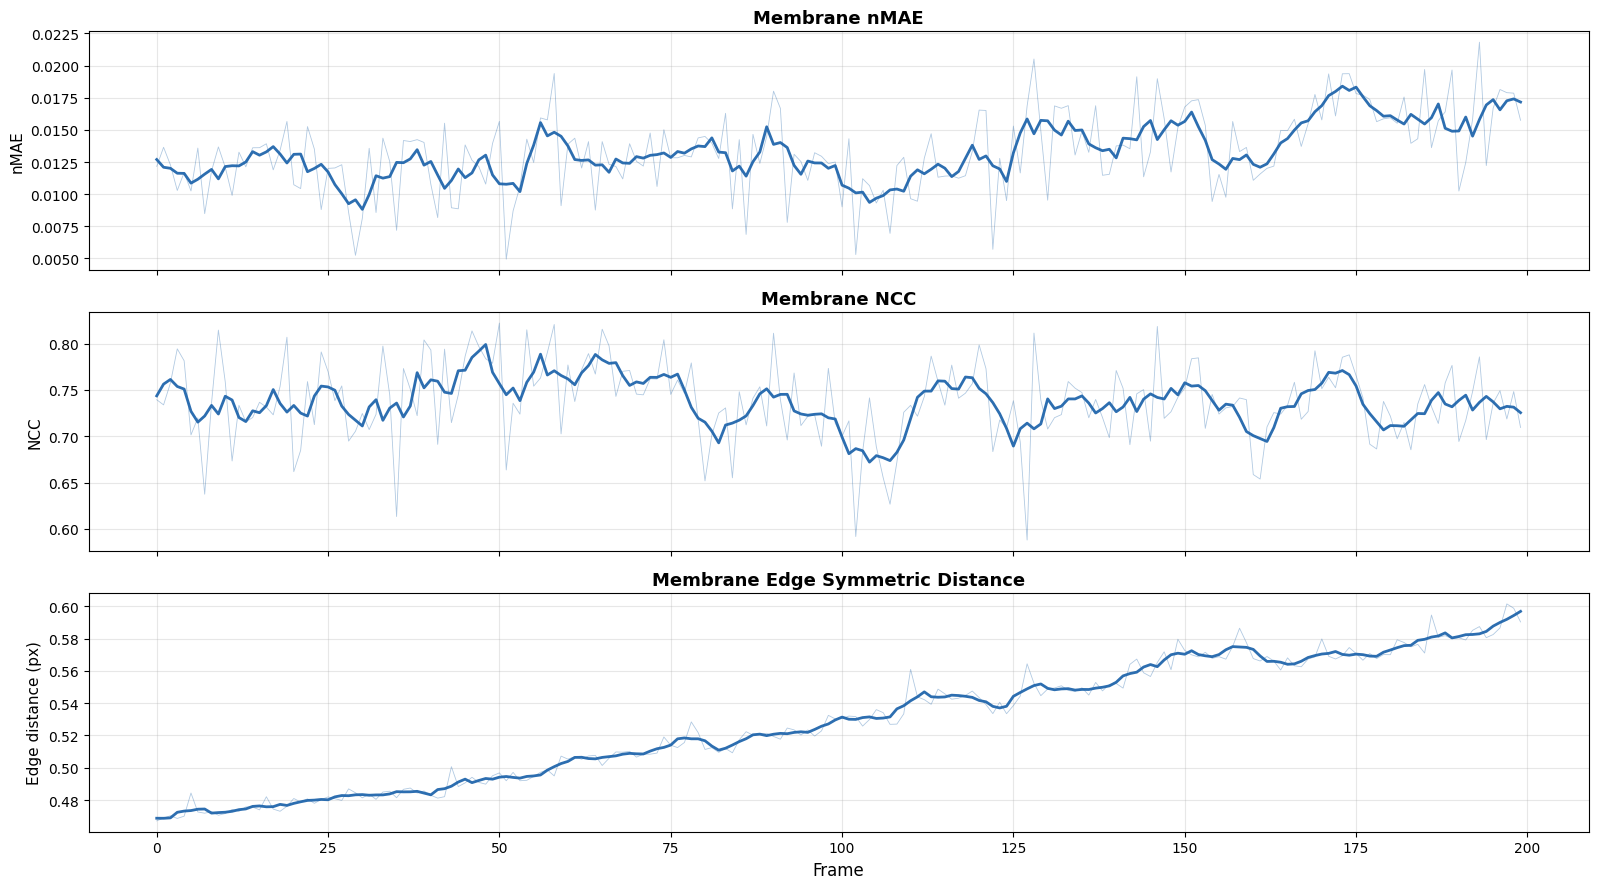

Saved to membrane_metrics_smoothed.png


In [7]:
# ================================================================
# Figure: 3-panel with rolling-window smoothing
# ================================================================
window = 5
df_mem["nMAE_smooth"] = df_mem["nMAE"].rolling(window, center=True, min_periods=1).mean()
df_mem["NCC_smooth"] = df_mem["NCC"].rolling(window, center=True, min_periods=1).mean()
df_mem["edge_smooth"] = df_mem["edge"].rolling(window, center=True, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

for ax, (col, smooth, ylabel, title) in enumerate(zip(
    ["nMAE", "NCC", "edge"],
    ["nMAE_smooth", "NCC_smooth", "edge_smooth"],
    ["nMAE", "NCC", "Edge distance (px)"],
    ["Membrane nMAE", "Membrane NCC", "Membrane Edge Symmetric Distance"])):
    ax = axes[ax]
    ax.plot(frames, df_mem[col], color=color_reg, lw=0.6, alpha=0.35)
    ax.plot(frames, df_mem[smooth], color=color_reg, lw=2.0, alpha=0.95)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel("Frame", fontsize=12)
fig.tight_layout()
fig.savefig(str(CSV_DIR.parent / "membrane_metrics_smoothed.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to membrane_metrics_smoothed.png")